In [ ]:
# https://www.kaggle.com/datasets/bhanupratapbiswas/fashion-products/discussion/450302
# Fashion Products
# fashion_products.csv

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('fashion_products.csv')
print("Первые 5 строк:")
print(df.head())
print("\nИнформация о датасете:")
print(df.info())

Первые 5 строк:
   User ID  Product ID Product Name   Brand         Category  Price    Rating  \
0       19           1        Dress  Adidas    Men's Fashion     40  1.043159   
1       97           2        Shoes     H&M  Women's Fashion     82  4.026416   
2       25           3        Dress  Adidas  Women's Fashion     44  3.337938   
3       57           4        Shoes    Zara    Men's Fashion     23  1.049523   
4       79           5      T-shirt  Adidas    Men's Fashion     79  4.302773   

    Color Size  
0   Black   XL  
1   Black    L  
2  Yellow   XL  
3   White    S  
4   Black    M  

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User ID       1000 non-null   int64  
 1   Product ID    1000 non-null   int64  
 2   Product Name  1000 non-null   object 
 3   Brand         1000 non-null   object 
 4   Cat

In [3]:
target_col = 'Category'
feature_cols = ['Product ID', 'Brand', 'Price', 'Rating', 'Color', 'Size']

In [4]:
le_dict = {}
for col in ['Brand', 'Color', 'Size']:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    le_dict[col] = le

In [5]:
le_target = LabelEncoder()
y = le_target.fit_transform(df[target_col])
print("\nКлассы:", le_target.classes_)


Классы: ["Kids' Fashion" "Men's Fashion" "Women's Fashion"]


In [7]:
X = df[['Price', 'Rating'] + [col + '_encoded' for col in ['Brand', 'Color', 'Size']]].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nРазмеры выборок:")
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


Размеры выборок:
(800, 5) (800,)
(200, 5) (200,)


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train.astype(np.int64))
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test.astype(np.int64))
print(X_train_tensor.shape, y_train_tensor.shape)

torch.Size([800, 5]) torch.Size([800])


In [11]:
print("Уникальные классы:", y_train_tensor.unique())

Уникальные классы: tensor([0, 1, 2])


In [12]:
length = y_train_tensor.shape[0]
num_classes = len(le_target.classes_)
y_onehot = torch.FloatTensor(length, num_classes)
y_onehot.zero_()
y_onehot.scatter_(1, y_train_tensor.view(-1, 1), 1)
print("\nПервые 5 меток:")
print(y_train_tensor[:5])
print("OneHot:")
print(y_onehot[:5])


Первые 5 меток:
tensor([0, 0, 1, 2, 0])
OneHot:
tensor([[1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.]])


In [13]:
D_in = X_train.shape[1]  # количество признаков
H = 100  # размер скрытого слоя
D_out = num_classes  # количество классов
print(f"\nПараметры модели: D_in={D_in}, H={H}, D_out={D_out}")


Параметры модели: D_in=5, H=100, D_out=3


In [14]:
net = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
    torch.nn.Softmax(dim=1)
)
print(net)

Sequential(
  (0): Linear(in_features=5, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=3, bias=True)
  (3): Softmax(dim=1)
)


In [18]:
def generate_batches(X, y, batch_size=32):
    for i in range(0, X.shape[0], batch_size):
        X_batch, y_batch = X[i:i+batch_size], y[i:i+batch_size]
        yield X_batch, y_batch

In [19]:
BATCH_SIZE = 32
NUM_EPOCHS = 200
loss_fn = torch.nn.CrossEntropyLoss()
learning_rate = 0.01
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

In [20]:
train_losses = []
train_accuracies = []

print("\nНачало обучения...")
for epoch_num in range(NUM_EPOCHS):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0
    num_batches = 0
    
    for i, (X_batch, y_batch) in enumerate(generate_batches(X_train_tensor, y_train_tensor, BATCH_SIZE)):
        y_pred = net(X_batch)
        loss = loss_fn(y_pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(y_pred, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        num_batches += 1
    
    epoch_loss = running_loss / num_batches
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    if (epoch_num + 1) % 20 == 0:
        print(f'Эпоха {epoch_num + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')


Начало обучения...
Эпоха 20/200, Loss: 1.0314, Accuracy: 50.62%
Эпоха 40/200, Loss: 0.9890, Accuracy: 56.88%
Эпоха 60/200, Loss: 0.9634, Accuracy: 60.62%
Эпоха 80/200, Loss: 0.9436, Accuracy: 62.62%
Эпоха 100/200, Loss: 0.9257, Accuracy: 64.62%
Эпоха 120/200, Loss: 0.9020, Accuracy: 67.50%
Эпоха 140/200, Loss: 0.8931, Accuracy: 67.75%
Эпоха 160/200, Loss: 0.8747, Accuracy: 70.12%
Эпоха 180/200, Loss: 0.8722, Accuracy: 69.88%
Эпоха 200/200, Loss: 0.8671, Accuracy: 69.38%


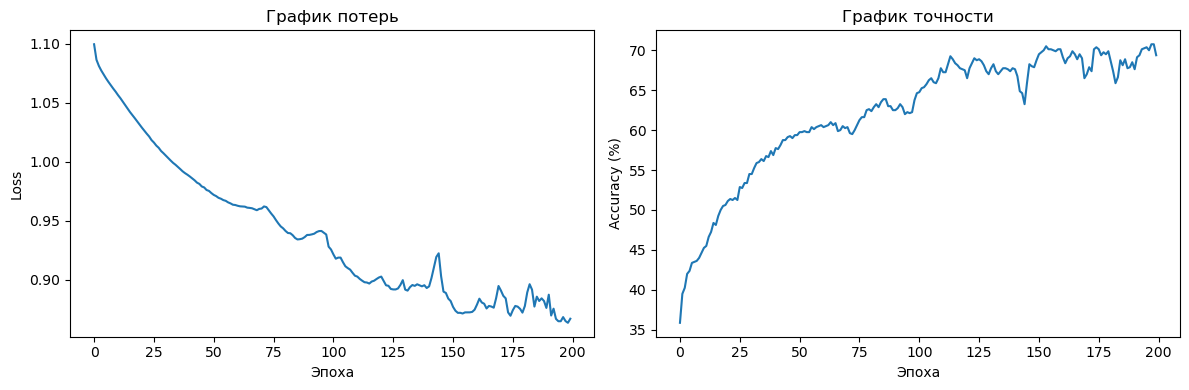

In [21]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('График потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title('График точности')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

In [22]:
net.eval()
with torch.no_grad():
    y_pred = net(X_test_tensor)
    _, predicted = torch.max(y_pred, 1)
    test_accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor) * 100
    print(f'\nТочность на тестовой выборке: {test_accuracy:.2f}%')


Точность на тестовой выборке: 34.50%


In [23]:
class_correct = list(0. for i in range(num_classes))
class_total = list(0. for i in range(num_classes))

with torch.no_grad():
    for X_batch, y_batch in generate_batches(X_test_tensor, y_test_tensor, BATCH_SIZE):
        y_pred = net(X_batch)
        _, predicted = torch.max(y_pred, 1)
        c = (predicted == y_batch).squeeze()
        for i in range(len(y_batch)):
            label = y_batch[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

print("\nТочность по классам:")
for i in range(num_classes):
    if class_total[i] > 0:
        print(f'  {le_target.classes_[i]}: {100 * class_correct[i] / class_total[i]:.2f}%')


Точность по классам:
  Kids' Fashion: 36.76%
  Men's Fashion: 29.41%
  Women's Fashion: 37.50%


In [24]:
print("\nПримеры предсказаний:")
with torch.no_grad():
    for i in range(10):
        idx = np.random.randint(0, len(X_test_tensor))
        pred = net(X_test_tensor[idx].unsqueeze(0))
        _, pred_class = torch.max(pred, 1)
        print(f'  Истинный класс: {le_target.classes_[y_test_tensor[idx]]}, Предсказанный: {le_target.classes_[pred_class.item()]}')


Примеры предсказаний:
  Истинный класс: Women's Fashion, Предсказанный: Men's Fashion
  Истинный класс: Men's Fashion, Предсказанный: Men's Fashion
  Истинный класс: Women's Fashion, Предсказанный: Men's Fashion
  Истинный класс: Women's Fashion, Предсказанный: Women's Fashion
  Истинный класс: Kids' Fashion, Предсказанный: Men's Fashion
  Истинный класс: Men's Fashion, Предсказанный: Kids' Fashion
  Истинный класс: Women's Fashion, Предсказанный: Women's Fashion
  Истинный класс: Women's Fashion, Предсказанный: Kids' Fashion
  Истинный класс: Women's Fashion, Предсказанный: Women's Fashion
  Истинный класс: Kids' Fashion, Предсказанный: Kids' Fashion
